In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [67]:
df=pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [68]:
df.info()
# null values - present, object datatype - present

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [69]:
(df.isnull().sum()/len(df))*100
# age missing values between 4-40 - replace value with mean or median
# depending on distribution
# Cabin > 40% missing values - drop the column
# Embarked <4% missing values - drop the rows.

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<Axes: xlabel='Age', ylabel='Density'>

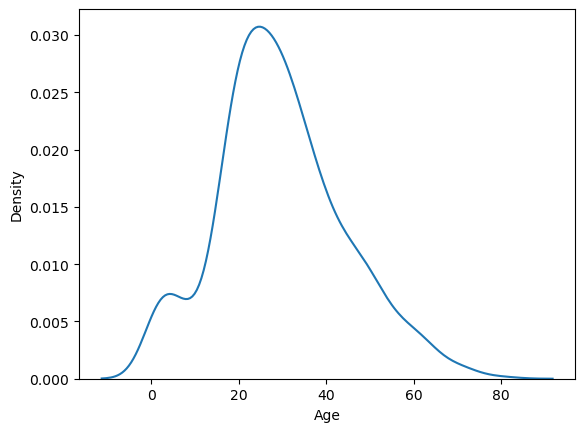

In [70]:







sns.kdeplot(df["Age"]) # skewness present

In [71]:
df["Age"].fillna(df["Age"].median(), inplace=True)

In [72]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)

In [73]:
df.drop("Cabin",axis=1,inplace=True)

In [74]:
df.isnull().sum()/len(df)

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [75]:
#1. Null removal
# 2. outlier check and processing

In [76]:
num_cols= df.select_dtypes(["float","int"]).columns
num_cols

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [77]:
df.head(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S


In [78]:
df=df.drop(["PassengerId","Name","Ticket"],axis=1)

In [79]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [80]:
num_cols= df.select_dtypes(["float","int"]).columns
num_cols
# based on the o/p not all float / int type columns are continous

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

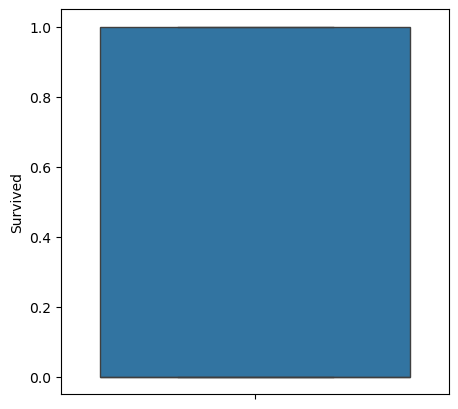

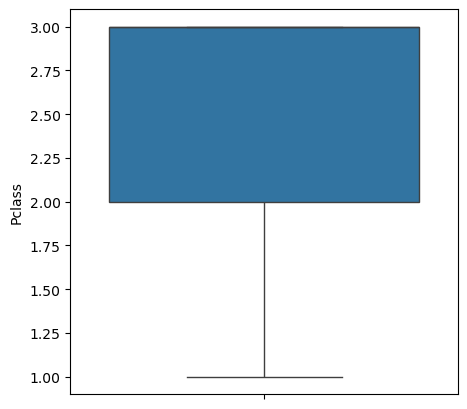

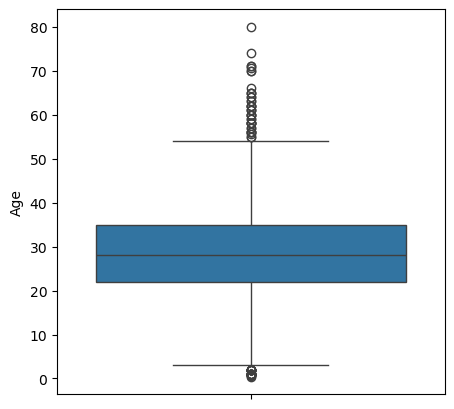

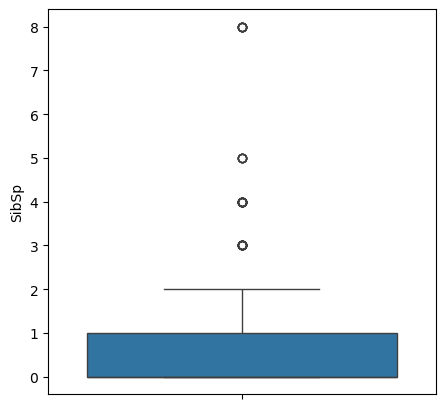

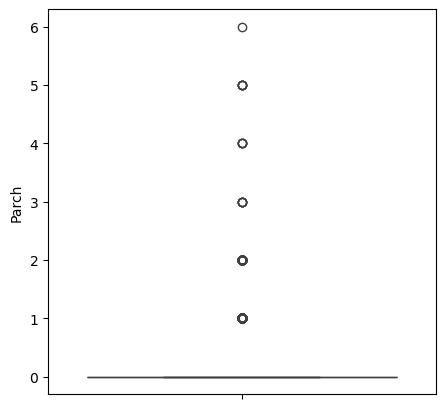

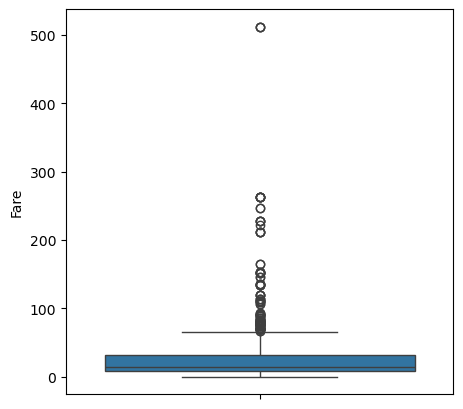

In [81]:
for i in num_cols:
    plt.figure(figsize=(5,5))
    sns.boxplot(df[i])
    plt.show()

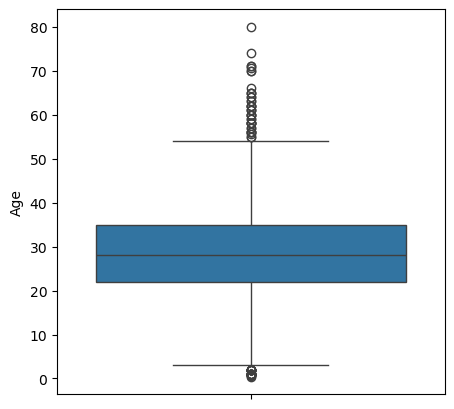

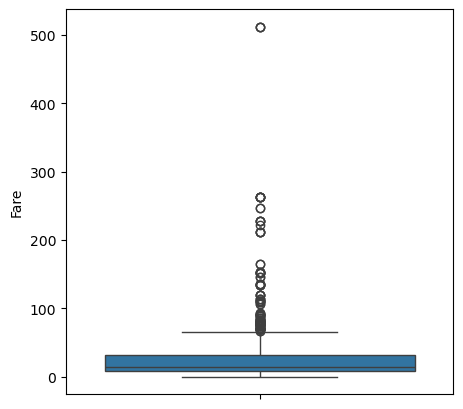

In [82]:
num_cols=["Age","Fare"]
for i in num_cols:
    plt.figure(figsize=(5,5))
    sns.boxplot(df[i])
    plt.show()

In [83]:
# so keeping outliers.

In [84]:
num_cols

['Age', 'Fare']

In [85]:
from scipy.stats import skew
# skewness check
for i in num_cols:
    print(f"{i} : {skew(df[i])}")
# Fare is very highly skewed, possible outlier presence
# but not removing as this might impact survival chance

Age : 0.5093852558219663
Fare : 4.7792532923723545


In [86]:
# object encoding
obj_cols=df.select_dtypes("object").columns
obj_cols

Index(['Sex', 'Embarked'], dtype='object')

In [87]:
for i in obj_cols:
    print(f"{i} : {df[i].nunique()} \n{df[i].value_counts()}")

Sex : 2 
Sex
male      577
female    314
Name: count, dtype: int64
Embarked : 3 
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


In [88]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[obj_cols]=oe.fit_transform(df[obj_cols])
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1.0,22.0,1,0,7.2500,2.0
1,1,1,0.0,38.0,1,0,71.2833,0.0
2,1,3,0.0,26.0,0,0,7.9250,2.0


Survived


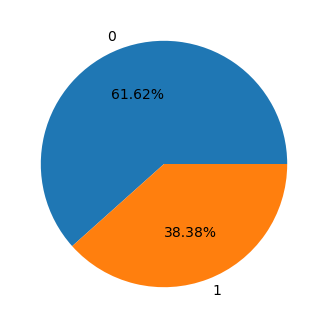

Pclass


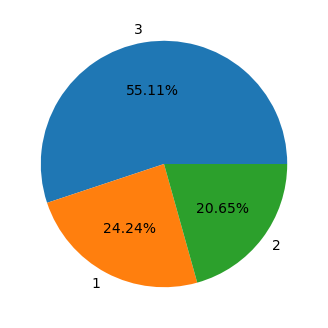

Sex


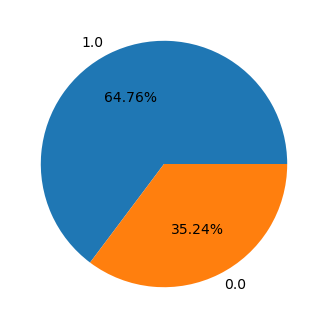

SibSp


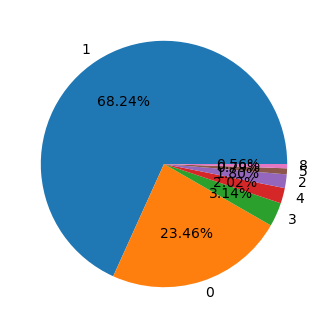

Parch


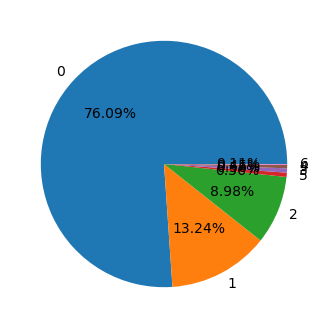

Embarked


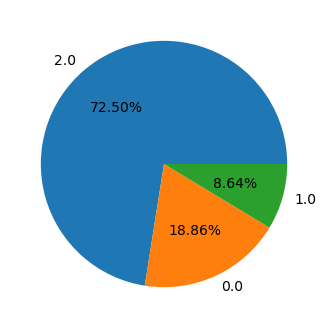

In [89]:
obj_cols=df.drop(["Age","Fare"],axis=1)
for i in obj_cols:
    print(i)
    plt.figure(figsize=(4,4))
    plt.pie(df[i].value_counts(),autopct="%.2f%%",labels=df[i].unique())
    plt.show()

In [90]:
df["family_size"]=df["SibSp"]+df["Parch"]
df=df.drop(["SibSp","Parch"],axis=1)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,family_size
0,0,3,1.0,22.0,7.2500,2.0,1
1,1,1,0.0,38.0,71.2833,0.0,1
2,1,3,0.0,26.0,7.9250,2.0,0
3,1,1,0.0,35.0,53.1000,2.0,1
4,0,3,1.0,35.0,8.0500,2.0,0


In [91]:
#in logistic regression feature selection is not possible
# so one of the ways features were selected on intutions with the help of visualizations

In [92]:
obj_cols=["Survived","Pclass","Sex","Embarked","family_size"]

Survived


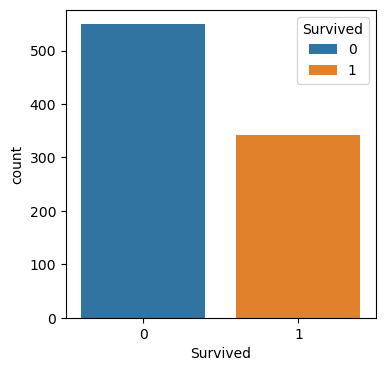

Pclass


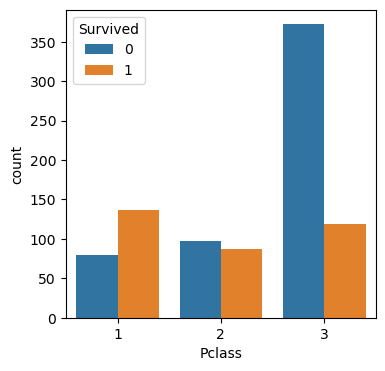

Sex


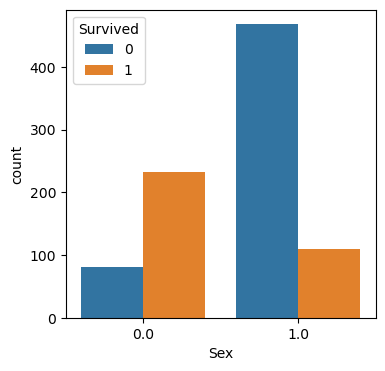

Embarked


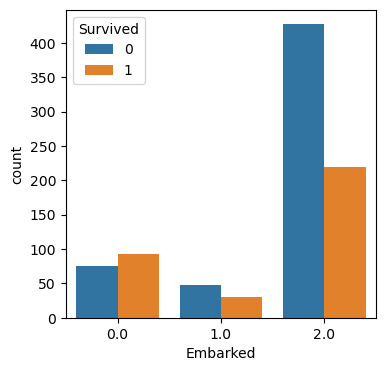

family_size


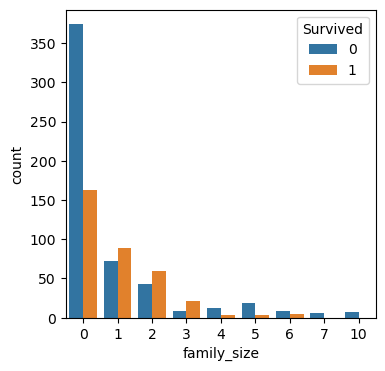

In [93]:
for i in obj_cols:
    print(f"{i}")
    plt.figure(figsize=(4,4))
    sns.countplot(data=df,x=df[i],hue="Survived")
    plt.show()

Age


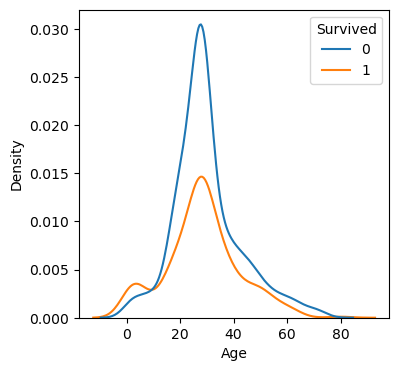

Fare


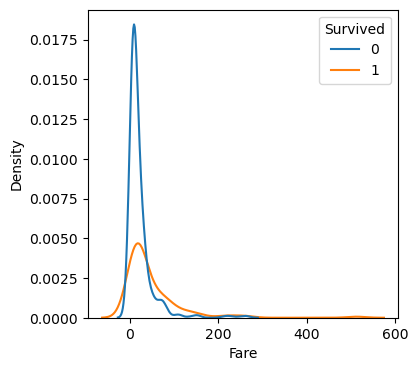

In [94]:
for i in num_cols:
    print(f"{i}")
    plt.figure(figsize=(4,4))
    sns.kdeplot(data=df,x=df[i],hue="Survived")
    plt.show()

In [95]:
features=df.drop("Survived",axis=1)
target=df["Survived"]

In [96]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
features_scaled=ss.fit_transform(features.iloc[:])
features=pd.DataFrame(features_scaled,columns=features.columns)
features.head()

,Pclass,Sex,Age,Fare,Embarked,family_size
0,0.827377,0.737695,-0.565736,-0.502445,0.585954,0.059160
1,-1.566107,-1.355574,0.663861,0.786845,-1.942303,0.059160
2,0.827377,-1.355574,-0.258337,-0.488854,0.585954,-0.560975
3,-1.566107,-1.355574,0.433312,0.420730,0.585954,0.059160
4,0.827377,0.737695,0.433312,-0.486337,0.585954,-0.560975


In [97]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(features,target,
                                           random_state=2,
                                           test_size=0.2)

In [98]:
xtest.shape

(179, 6)

In [99]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix

In [100]:
log_reg=LogisticRegression()
log_reg.fit(xtrain,ytrain)
ypred=log_reg.predict(xtest)

In [101]:
print(pd.DataFrame(confusion_matrix(ytest,ypred),
                   columns=["Not Survived","Survived"],
                   index=["Not Survived","Survived"])
     )

              Not Survived  Survived
Not Survived            89        11
Survived                28        51


In [102]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.76      0.89      0.82       100
           1       0.82      0.65      0.72        79

    accuracy                           0.78       179
   macro avg       0.79      0.77      0.77       179
weighted avg       0.79      0.78      0.78       179



In [103]:
# overfitting - underfitting check

In [104]:
print(f"Training Score : {log_reg.score(xtrain,ytrain)}")
print(f"Testing Score : {log_reg.score(xtest,ytest)}")

Training Score : 0.8103932584269663
Testing Score : 0.7821229050279329


In [105]:
# little overfitting

In [106]:
log_reg.predict_proba(xtest[:10])

array([[0.68395934, 0.31604066],
       [0.88942682, 0.11057318],
       [0.24005298, 0.75994702],
       [0.90570518, 0.09429482],
       [0.61186288, 0.38813712],
       [0.92199547, 0.07800453],
       [0.91576059, 0.08423941],
       [0.9053205 , 0.0946795 ],
       [0.7855464 , 0.2144536 ],
       [0.79505223, 0.20494777]])

In [107]:
print("Actual :",log_reg.predict(xtest[:10]))
print("Predicted :",ytest[:10].values)

Actual : [0 0 1 0 0 0 0 0 0 0]
Predicted : [1 0 1 0 1 0 1 0 1 0]


In [108]:
from sklearn.metrics import roc_auc_score,roc_curve
print(roc_auc_score(ytest,ypred))

0.7677848101265822


Text(0, 0.5, 'TPR')

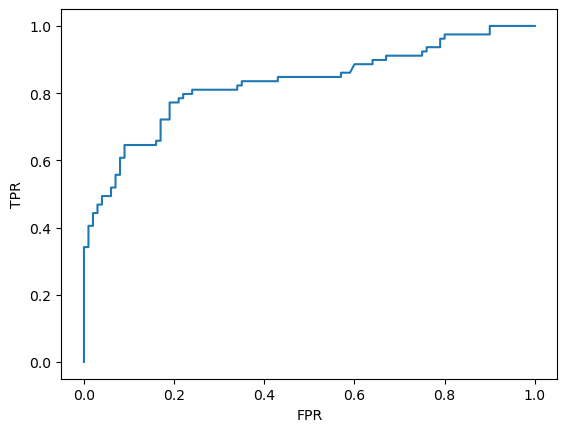

In [109]:
yp=log_reg.predict_proba(xtest)[:,1]
fpr,tpr,th=roc_curve(ytest,yp)
plt.plot(fpr,tpr)
plt.xlabel("FPR")
plt.ylabel("TPR")

In [110]:
th

array([       inf, 0.98079201, 0.79210666, 0.79039156, 0.74173923,
       0.73453655, 0.70336144, 0.6884414 , 0.68265037, 0.66716556,
       0.66637975, 0.65719763, 0.64938718, 0.6451204 , 0.62773   ,
       0.62574198, 0.59468165, 0.57838492, 0.54099995, 0.46668051,
       0.45893902, 0.45678849, 0.34460313, 0.327802  , 0.30376016,
       0.27217186, 0.23942129, 0.23844068, 0.23310991, 0.21595275,
       0.2144536 , 0.2113481 , 0.21047655, 0.14687332, 0.14607674,
       0.13934614, 0.12382056, 0.11481314, 0.1127384 , 0.09670167,
       0.09574462, 0.0946795 , 0.09429482, 0.08859849, 0.08771477,
       0.08452416, 0.08441734, 0.08440521, 0.08437529, 0.0843559 ,
       0.08435186, 0.08425009, 0.08423941, 0.08111031, 0.07900138,
       0.07800453, 0.07702132, 0.0565903 , 0.04445561, 0.0109868 ])

In [111]:
from sklearn.metrics import f1_score
re=[f1_score(ytest,(yp>i).astype(int)) for i in th]

In [112]:
re

[0.0,
 0.0,
 0.49523809523809526,
 0.5094339622641509,
 0.5585585585585585,
 0.5714285714285714,
 0.591304347826087,
 0.603448275862069,
 0.6101694915254238,
 0.6218487394957983,
 0.628099173553719,
 0.6341463414634146,
 0.64,
 0.6507936507936508,
 0.6666666666666666,
 0.676923076923077,
 0.7014925373134329,
 0.7111111111111111,
 0.7246376811594203,
 0.7034482758620689,
 0.6986301369863014,
 0.7074829931972789,
 0.7368421052631579,
 0.7402597402597403,
 0.759493670886076,
 0.7625,
 0.7577639751552795,
 0.7654320987654321,
 0.7607361963190185,
 0.7636363636363637,
 0.7590361445783133,
 0.7664670658682635,
 0.7619047619047619,
 0.7272727272727273,
 0.7231638418079096,
 0.7303370786516854,
 0.7262569832402235,
 0.7058823529411765,
 0.7021276595744681,
 0.6633663366336634,
 0.6600985221674877,
 0.6634146341463415,
 0.6601941747572816,
 0.660377358490566,
 0.6572769953051644,
 0.6574074074074074,
 0.6543778801843319,
 0.6605504587155964,
 0.6545454545454545,
 0.64,
 0.6371681415929203,
 0.6

In [113]:
best_th=th[np.argmax(re)]
best_th

np.float64(0.21134809658405926)

In [114]:
from sklearn.preprocessing import binarize
ypred_proba=log_reg.predict_proba(xtest)[:,1]
ypr=binarize([ypred_proba],threshold=best_th)[0]

In [115]:
ypr=ypr.astype(int)
print("roc_score : ",roc_auc_score(ytest,ypred))

roc_score :  0.7677848101265822


In [116]:
print(pd.DataFrame(confusion_matrix(ytest,ypr),
                   columns=["Not Survived","Survived"],
                   index=["Not Survived","Survived"])
     )

              Not Survived  Survived
Not Survived            76        24
Survived                15        64


In [117]:
print(classification_report(ytest,ypr))

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.73      0.81      0.77        79

    accuracy                           0.78       179
   macro avg       0.78      0.79      0.78       179
weighted avg       0.79      0.78      0.78       179



In [122]:
from sklearn.decomposition import PCA
pca=PCA(n_components=4)
xtrain_pca=pca.fit_transform(xtrain)
xtest_pca=pca.transform(xtest)

In [123]:
print(xtrain_pca.shape)
print(xtest_pca.shape)

(712, 4)
(179, 4)


In [124]:
def mymodel(model):
    model.fit(xtrain_pca,ytrain)
    ypred=model.predict(xtest_pca)
    # overfitting underfitting check
    print(f"Training Score : {model.score(xtrain_pca,ytrain)}")
    print(f"Testing Score : {model.score(xtest_pca,ytest)}")
    print(pd.DataFrame(confusion_matrix(ytest,ypred),
                   columns=["Not Survived","Survived"],
                   index=["Not Survived","Survived"])
     )
    print(classification_report(ytest,ypred))
    return model

In [125]:
mymodel(LogisticRegression())

Training Score : 0.7865168539325843
Testing Score : 0.7597765363128491
              Not Survived  Survived
Not Survived            86        14
Survived                29        50
              precision    recall  f1-score   support

           0       0.75      0.86      0.80       100
           1       0.78      0.63      0.70        79

    accuracy                           0.76       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.76      0.76       179



LogisticRegression()